In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
#%cd /content/drive/MyDrive

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib import style
from collections import Counter
import seaborn as sns
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)
import nltk
nltk.download('omw-1.4')
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('wordnet')
from nltk import word_tokenize,sent_tokenize 
import string
string.punctuation
from nltk.stem import PorterStemmer,LancasterStemmer 
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer  
from nltk import ne_chunk
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import TruncatedSVD,LatentDirichletAllocation,NMF
from sklearn.preprocessing import normalize

import datetime
# graph
from wordcloud import WordCloud

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
data = pd.read_csv('abcnews-date-text.csv')
print(data.shape)

(1226258, 2)


In [5]:
date_sorted = sorted(list(data['publish_date']))
print(date_sorted[0], date_sorted[-1])

20030219 20201231


<AxesSubplot:title={'center':'Counts of Headline of Years'}, xlabel='publish_date'>

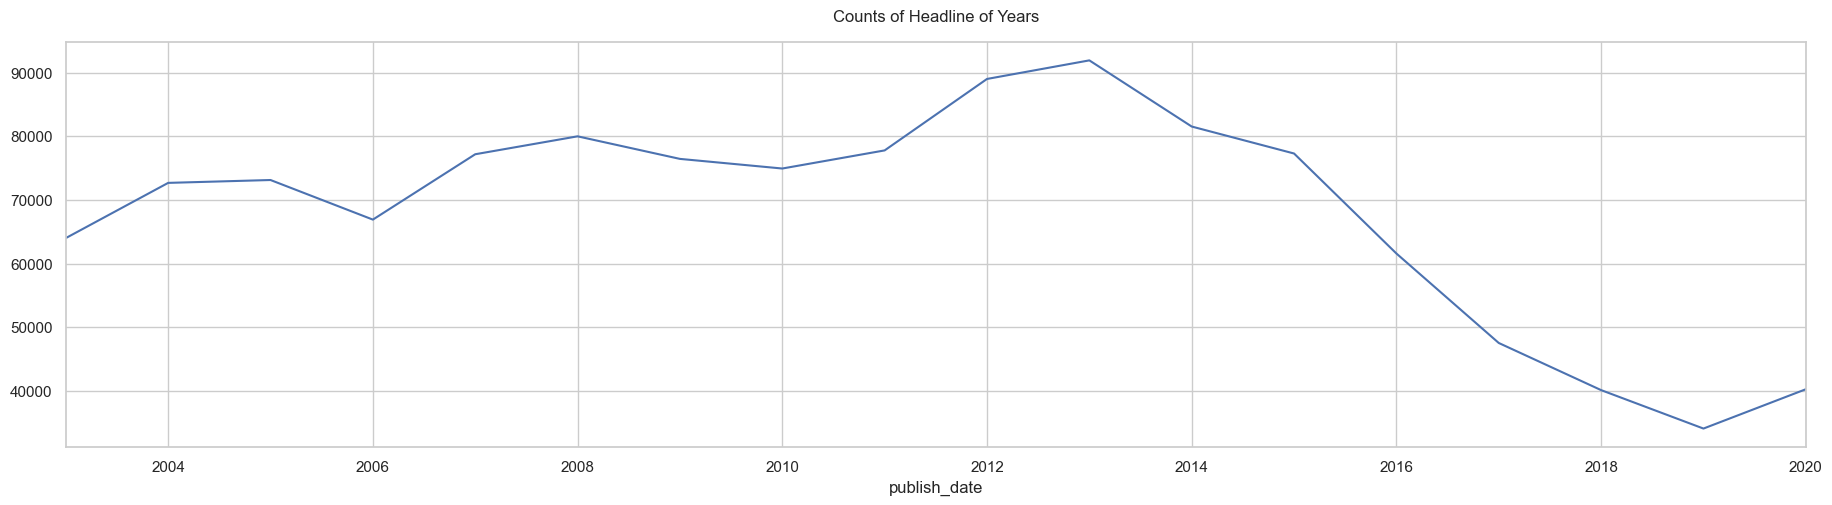

In [6]:
plt.figure(figsize=(20,5),dpi=100,linewidth = 2)
plt.title("Counts of Headline of Years", x=0.5, y=1.03)
data['publish_date'] = pd.to_datetime(data['publish_date'], format="%Y%m%d")
data.resample('A',on = 'publish_date')['headline_text'].count().plot(kind='line')

In [7]:
#data.drop(['publish_date'], axis=1, inplace=True)
#data.head()

Data Clean

In [8]:
stop_words=set(nltk.corpus.stopwords.words('english'))
print(stop_words)

{'t', 'his', 'of', 'ain', 'won', 'again', 'the', "mustn't", 'some', "couldn't", 'haven', 'him', 'why', 'herself', "haven't", 'shouldn', "won't", 'wouldn', "mightn't", 'through', 'just', 'now', 'then', 'very', 'not', "isn't", 'myself', 'this', 'further', 'nor', 'be', "you've", 'both', 'theirs', 'so', 'after', 'i', 'he', "doesn't", "aren't", 'too', 'at', 'once', 'out', 'down', 'more', 'had', 'mightn', 'into', 'being', "that'll", "don't", 'has', 'can', 'few', 's', 'against', "should've", 'up', 'when', 'we', 'o', 'there', 'between', 'than', 'her', 'such', 'in', 'do', 'during', 'weren', 'themselves', 'is', "it's", 'it', 'above', 'any', 'over', 'who', 'but', 'because', 'their', 'ours', 'ma', 'whom', 'before', 've', 'were', 'on', 'should', 'our', 'itself', 'doesn', 'couldn', 'yourselves', 'only', 'will', "shouldn't", 'himself', 'own', 'have', "wouldn't", 'me', 'under', 'with', 'other', 'd', 'here', "shan't", 'about', 'until', "hadn't", 'most', 'all', 'no', 'hadn', 'hasn', 'what', 'she', 'll',

In [9]:
# Remove duplicated headlines
data = data.drop_duplicates(subset=['headline_text'], keep = False)
print(data.shape)

(1185953, 2)


In [10]:
def clean_text(headLine):
  le=WordNetLemmatizer()
  word_tokens=word_tokenize(headLine)
  
  # remove stopword, punctuation
  tokens=[le.lemmatize(w) for w in word_tokens if w not in stop_words and len(w) > 3 and w not in string.punctuation]
  cleaned_text=" ".join(tokens)
  return cleaned_text

In [11]:
data['headline_cleaned']=data['headline_text'].apply(clean_text)
data.head()

,publish_date,headline_text,headline_cleaned
0,2003-02-19,aba decides against community broadcasting lic...,decides community broadcasting licence
1,2003-02-19,act fire witnesses must be aware of defamation,fire witness must aware defamation
2,2003-02-19,a g calls for infrastructure protection summit,call infrastructure protection summit
3,2003-02-19,air nz staff in aust strike for pay rise,staff aust strike rise
4,2003-02-19,air nz strike to affect australian travellers,strike affect australian traveller


In [12]:
print(sum([len(w.split()) for w in data['headline_text']]))
print(sum([len(w.split()) for w in data['headline_cleaned']]))

7859785
5818238


In [13]:
data.drop(['headline_text'], axis=1, inplace=True)
data.head()

,publish_date,headline_cleaned
0,2003-02-19,decides community broadcasting licence
1,2003-02-19,fire witness must aware defamation
2,2003-02-19,call infrastructure protection summit
3,2003-02-19,staff aust strike rise
4,2003-02-19,strike affect australian traveller


Using TFidf to extract the features

In [14]:
vec = TfidfVectorizer(stop_words=stop_words,max_features=1000)
vec_text=vec.fit_transform(data['headline_cleaned'])
print(vec_text)

  (0, 509)	0.7833555043157009
  (0, 178)	0.6215739327371232
  (1, 577)	0.6333845621342471
  (1, 983)	0.6360176173661909
  (1, 321)	0.4408010740116697
  (2, 853)	0.6542250319692703
  (2, 683)	0.6234831415977256
  (2, 122)	0.428086883340564
  (3, 744)	0.4539046227610106
  (3, 845)	0.4908474048522162
  (3, 54)	0.5221131804007425
  (3, 829)	0.5295632591464885
  (4, 56)	0.6371206308422673
  (4, 845)	0.7707641025340705
  (5, 978)	1.0
  (6, 710)	1.0
  (7, 544)	0.5177841426380108
  (7, 344)	0.4818749914563097
  (7, 961)	0.5353169396784209
  (7, 53)	0.46166204991847815
  (8, 453)	0.4300409765947477
  (8, 200)	0.3490490663814993
  (8, 777)	0.44823205361768437
  (8, 13)	0.5218790075893285
  (8, 54)	0.46899875826582976
  :	:
  (1185944, 834)	0.377563949138926
  (1185945, 98)	0.5661259082792712
  (1185945, 942)	0.5044737182741936
  (1185945, 550)	0.46222895776789946
  (1185945, 135)	0.45973047989706
  (1185946, 343)	0.6087468731112728
  (1185946, 970)	0.7933645092120317
  (1185947, 502)	0.625754601

In [25]:
headline_cleaned = data['headline_cleaned']
headline_cleaned_first200 = headline_cleaned[:200]
print(headline_cleaned_first200.head)

<bound method NDFrame.head of 0       decides community broadcasting licence
1           fire witness must aware defamation
2        call infrastructure protection summit
3                       staff aust strike rise
4           strike affect australian traveller
                        ...                   
196             wine chief bounce back sacking
197     worksafe probe potato harvester injury
198    dead rebel bombing raid philippine army
199                              abattoir sale
200    academic upbeat higher education review
Name: headline_cleaned, Length: 200, dtype: object>


In [27]:
df_copy = pd.DataFrame(
    vec_text.toarray(), 
    columns=vec.get_feature_names_out(), 
    index=headline_cleaned_first200
    )

df_copy.head()

,2500,61st,abandon,abattoir,aboriginal,academic,access,accidental,accusation,accused,...,woe,wollongong,woman,work,worksafe,world,young,youth,zealand,zimbabwe
headline_cleaned,,,,,,,,,,,,,,,,,,,,,
decides community broadcasting licence,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fire witness must aware defamation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
call infrastructure protection summit,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
staff aust strike rise,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
strike affect australian traveller,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
idf_df = pd.DataFrame(
    vec.idf_, 
    index=vec.get_feature_names(),
    columns=['idf_weigths']
    )
    
idf_df.sort_values(by=['idf_weigths']).head(10)

c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,idf_weigths
iraq,4.223863
korean,4.223863
plan,4.223863
fund,4.357395
back,4.357395
fire,4.357395
council,4.357395
urged,4.511545
subway,4.511545
public,4.511545


In [29]:
vec = TfidfVectorizer(stop_words=stop_words,max_features=1000)
vec_text=vec.fit_transform(headline_cleaned_first200)

In [30]:
# select number of topic clusters
n_topics = 25

# Create an NMF instance
nmf = NMF(n_components=n_topics)

# Fit the model to the tf_idf
nmf_features = nmf.fit_transform(vec_text)

# normalize the features
norm_features = normalize(nmf_features)

c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(


In [31]:
# Compare processed VS unprocessed dataframes
print('Original df: ', df_copy.shape)
print('NMF Processed df: ', nmf.components_.shape)

Original df:  (200, 693)
NMF Processed df:  (25, 693)


In [32]:
# Create clustered dataframe the NMF clustered df
components = pd.DataFrame(
    nmf.components_, 
    columns=[df_copy.columns]
    ) 

clusters = {}

# Show top 25 queries for each cluster
for i in range(len(components)):
    clusters[i] = []
    loop = dict(components.loc[i,:].nlargest(25)).items()
    for k,v in loop:
        clusters[i].append({'q':k[0],'sim_score': v})

In [33]:
# Create dataframe using the clustered dictionary
grouping = pd.DataFrame(clusters).T
grouping['topic'] = grouping[0].apply(lambda x: x['q'])
grouping.drop(0, axis=1, inplace=True)
grouping.set_index('topic', inplace=True)

def show_queries(df):
    for col in df.columns:
        df[col] = df[col].apply(lambda x: x['q'])
    return df

# Only display the query in the dataframe
clustered_queries = show_queries(grouping)
clustered_queries.head()

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
topic,,,,,,,,,,,,,,,,,,,,,
korean,subway,continues,south,still,missing,search,toll,victim,climb,death,...,grows,question,anger,help,asylum,japanese,seek,fisherman,sign,public
embassy,raid,aboriginal,tent,fined,defends,defend,police,asylum,japanese,seek,...,bombing,korean,campaign,running,race,2500,61st,abandon,abattoir,academic
council,welcome,insurance,breakthrough,local,polling,single,decision,ambulance,levy,move,...,chief,executive,fails,position,secure,introduce,address,security,aust,iraq
fund,allocated,cadell,cemetery,miss,upgrade,risk,work,youth,domestic,violence,...,victim,help,closure,mill,rice,search,drug,crop,discovered,massive
plan,revealed,second,skatepark,industry,sugar,sanctuary,wildlife,move,bathhouse,ahead,...,2500,job,outrage,union,paroo,supply,qantas,boost,water,garden


In [39]:
d = {}
pages = headline_cleaned_first200
# create dataframe
norm_df = pd.DataFrame(norm_features, index=pages)
for page in pages:

    # select page recommendations
        recommendations = norm_df.loc[page,:]

        if(recommendations.shape == (25,)):
            # Compute cosine similarity
            similarities = norm_df.dot(recommendations)

            d[page] = []
            loop = dict(similarities.nlargest(10)).items()
            for k, v in loop:
                if k != page:
                    d[page].append({'q':k,'sim_score': v})

print(d)

{'decides community broadcasting licence': [{'q': 'councillor contest wollongong independent', 'sim_score': 0.9999979042961038}, {'q': 'opposition urged help protect recherche', 'sim_score': 0.9995038610771253}, {'q': 'community urged help homeless youth', 'sim_score': 0.9965069811623533}, {'q': 'bushfire victim urged centrelink', 'sim_score': 0.9961126028385487}, {'q': 'woman urged become councillor', 'sim_score': 0.9912688096097152}, {'q': 'public urged check cylinder', 'sim_score': 0.7802671519067573}, {'q': 'fund help restore cossack', 'sim_score': 0.31526121346383956}, {'q': 'dying korean subway passenger phoned help', 'sim_score': 0.29776598581436287}, {'q': 'council move protect heritage garden', 'sim_score': 0.29177748085991373}], 'fire witness must aware defamation': [{'q': 'stock feed pellet fire affected', 'sim_score': 0.9428927716007791}, {'q': 'gilchrist back rest policy', 'sim_score': 0.9410703961317954}, {'q': 'gold coast hear bilby project', 'sim_score': 0.9410703961317

In [42]:
# convert dictionary to dataframe
recommender = pd.DataFrame(d).T

def show_queries(df):
    for col in df.columns:
        df[col] = df[col].apply(lambda x: x['q'])
    return df

show_queries(recommender).head()

ValueError: All arrays must be of the same length

In [ ]:
textIDF = vec.idf_
dd=dict(zip(vec.get_feature_names_out(), textIDF))
textList=sorted(dd,key=(dd).get)
print(textList[0], textList[-1])
print(dd['police'])
print(dd['justice'])
    

In [ ]:
# Define helper functions
def get_keys(topic_matrix):
    '''
    returns an integer list of predicted topic 
    categories for a given topic matrix
    '''
    keys = topic_matrix.argmax(axis=1).tolist()
    return keys

def keys_to_counts(keys):
    '''
    returns a tuple of topic categories and their 
    accompanying magnitudes for a given list of keys
    '''
    count_pairs = Counter(keys).items()
    categories = [pair[0] for pair in count_pairs]
    counts = [pair[1] for pair in count_pairs]
    return (categories, counts)

In [ ]:
big_sample_size = 100000 

headline = data['headline_cleaned']
headline.index = data['publish_date']

big_count_vectorizer = CountVectorizer(stop_words='english', max_features=40000)
big_text_sample = headline.sample(n=big_sample_size, random_state=0).values
big_document_term_matrix = big_count_vectorizer.fit_transform(big_text_sample)

big_lda_model = LatentDirichletAllocation(n_components=5, learning_method='online')
big_lda_model.fit(big_document_term_matrix);

yearly_data = []
for i in range(2003,2020+1):
    yearly_data.append(headline['{}'.format(i)].values)

yearly_topic_matrices = []
for year in yearly_data:
    document_term_matrix = big_count_vectorizer.transform(year)
    topic_matrix = big_lda_model.transform(document_term_matrix)
    yearly_topic_matrices.append(topic_matrix)

yearly_keys = []
for topic_matrix in yearly_topic_matrices:
    yearly_keys.append(get_keys(topic_matrix))
    
yearly_counts = []
for keys in yearly_keys:
    categories, counts = keys_to_counts(keys)
    yearly_counts.append(counts)

yearly_topic_counts = pd.DataFrame(np.array(yearly_counts), index=range(2003,2020+1))
yearly_topic_counts.columns = ['Topic {}'.format(i+1) for i in range(5)]

print(yearly_topic_counts)

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
sb.heatmap(yearly_topic_counts, cmap="YlGnBu", ax=ax);
plt.show()

In [ ]:
dd_sorted = dict(sorted(dd.items(), key=lambda item: item[1]))
n = 10
first_ten = dict(zip(list(dd_sorted.keys())[:n], list(dd_sorted.values())[:n]))
print(first_ten)

print("Hot Topic")
plt.figure(figsize=(7,3))
plt.bar(list(first_ten.keys()), list(first_ten.values()))

Topic Modeling

In [ ]:
LSA_model=TruncatedSVD(n_components=10, algorithm='randomized', n_iter=10, random_state=42)
LSA_top=LSA_model.fit_transform(vec_text)
print(LSA_top.shape)
print(LSA_top)

In [ ]:
l=LSA_top[0]
print("Document 0 :")
for i,topic in enumerate(l):
  print("Topic ",i," : ",topic*100)

In [ ]:
# get most related words of the topic
top_words = vec.get_feature_names_out()

for i, c in enumerate(LSA_model.components_):
  top_topic = ""
  top_words_c = zip(top_words, c)
  words_s = sorted(top_words_c, key= lambda x:x[1], reverse=True)[:50]
  print("Topic " + str(i) + ": ")
  for w in words_s:
    top_topic = top_topic + " " + w[0]

  
  wc = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(top_topic)
  plt.figure(figsize=(5,5))
  plt.imshow(wc)
  plt.axis("off")
  plt.show()